# Part VI — Linear Algebra
## Chapters 151–200

> *"The purpose of computing is insight, not numbers."* — Richard Hamming

---

## What This Part Covers

Part VI is the structural core of this book. Every major algorithm in machine learning — linear regression, neural networks, PCA, SVD-based compression, recommender systems — is, at its heart, a sequence of matrix operations. This part builds that foundation from scratch.

We start with matrices as notation, move quickly to matrices as transformations, and then spend the majority of the part on the three ideas that unlock modern ML:

1. **Eigendecomposition** — what directions does a transformation preserve?
2. **Singular Value Decomposition** — the universal factorization of any matrix
3. **Matrix calculus** — how do we differentiate through matrix operations?

The part closes with 12 project chapters that apply these tools to real systems: image compression, face recognition, recommender systems, neural network layers, and more.

---

## The Mental Shift Required

In Part V, you learned to think in vectors: directed quantities with magnitude and direction. A single vector is a point in space, or an arrow, or a list of features.

**In Part VI, you stop thinking about individual vectors and start thinking about the machines that transform vector spaces.**

A matrix is not a table of numbers. A matrix is a function. It takes a vector space and warps it — stretching, rotating, reflecting, projecting, collapsing. Every matrix multiplication is a geometric event.

The shift:
- **Before:** vectors are things
- **After:** matrices are verbs applied to things

Once you internalize this, linear algebra stops being symbol manipulation and becomes spatial reasoning at scale.

---

## Part Map: What Connects to What

```
MATRIX BASICS                    TRANSFORMATIONS
ch151 Introduction          →    ch164 Linear Transformations
ch152 Representation        →    ch165 Visualization
ch153 Addition              →    ch166 Rotations
ch154 Multiplication        →    ch167 Scaling
ch155 Transpose             →    ch168 Projection Matrices
ch156 Identity              ↘
ch157 Inverse               →    EIGENSTRUCTURE
ch158 Determinants (intuit)      ch169 Eigenvectors Intuition
ch159 Determinants (comp)   →    ch170 Eigenvalues Intuition
                                 ch171 Eigenvalue Computation
SYSTEMS & FACTORIZATION          ch172 Diagonalization
ch160 Systems of Equations  ↘
ch161 Gaussian Elimination       DECOMPOSITIONS
ch162 Matrix Factorization  →    ch173 SVD
ch163 LU Decomposition           ch174 PCA Intuition
                                 ch175 Dimensionality Reduction

CALCULUS & ML BRIDGE             PROJECTS
ch176 Matrix Calculus       →    ch180–200 (12 applied projects)
ch177 Linear Algebra for NN
ch178 Linear Layers in DL
ch179 [Advanced: Gram-Schmidt]
```

---

## Prerequisites from Prior Parts

You must be solid on these before proceeding:

- **From Part V:** Vectors as lists of numbers, dot product *(ch131 — Dot Product Intuition)*, vector norms *(ch128 — Vector Length)*, linear combinations *(ch127)*, basis and linear independence *(ch139–141)*
- **From Part III:** Function composition *(ch054)*, the idea of a transformation as a function
- **From Part II:** Floating point precision *(ch038)* — matrix arithmetic accumulates numerical error; you need to know why
- **From Part IV:** Geometric transformations — rotation, scaling, reflection *(ch108–112)* — you already computed these by hand; now matrices will unify them

If dot products feel mechanical rather than geometric, go back to ch131–133 before continuing.

---

## Motivating Problem: You Cannot Yet Solve This

Here is a real problem. Run the code. Look at the output. You cannot fully explain it yet.

By the end of Part VI, every line will be transparent.

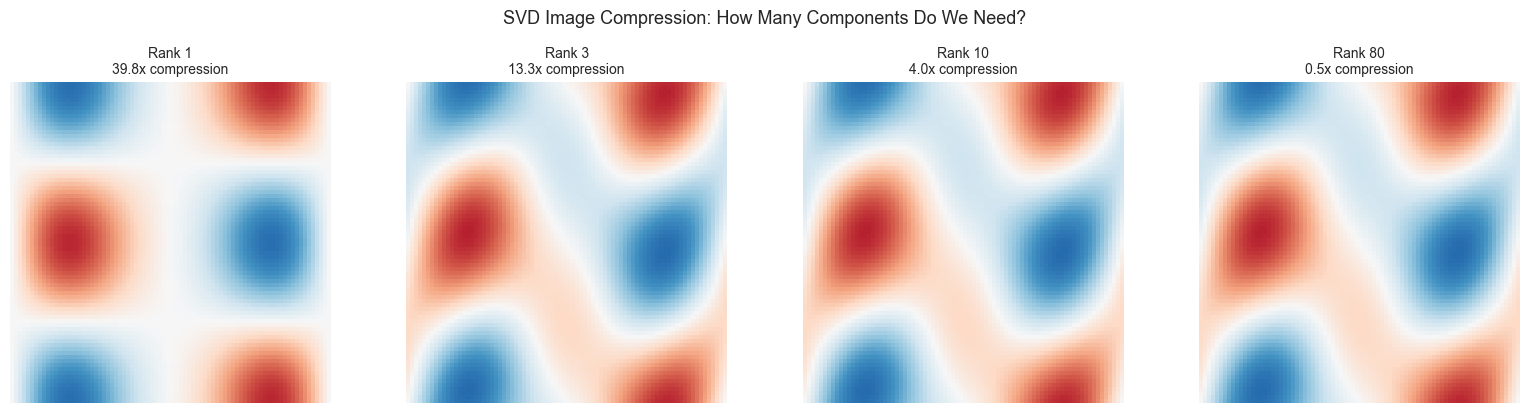

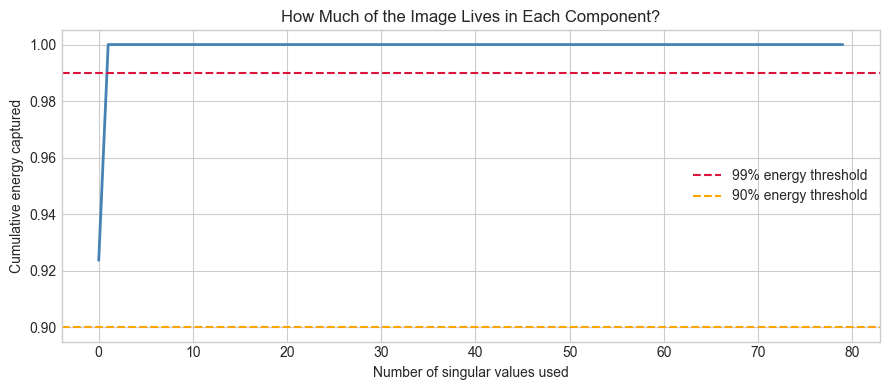

Image shape: (80, 80)  (6400 total numbers)
Singular values > 1% of max: 2
90% of energy captured by rank-1 approximation

Questions you cannot yet answer:
  1. What ARE U, S, Vt? What do they represent geometrically?
  2. Why does rank-3 capture almost the full image?
  3. Why is @ (matrix multiplication) the right operation here?
  4. What is an eigenvalue and how does it relate to S?
  5. Why can PCA be implemented as SVD?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# --- Motivating Problem: What Does This Image Contain? ---
# We generate a synthetic 'image' as a matrix of pixel intensities.
# Then we compress it using only 5 numbers per row instead of 50.
# How much information survives? How does that work mathematically?

np.random.seed(42)

# Construct a low-rank synthetic image: two overlapping gradients
x = np.linspace(0, 2 * np.pi, 80)
y = np.linspace(0, 2 * np.pi, 80)
X, Y = np.meshgrid(x, y)
image = np.sin(X) * np.cos(Y) + 0.3 * np.sin(2 * X + Y)

# SVD decomposition — the universal matrix factorization
U, S, Vt = np.linalg.svd(image, full_matrices=False)

# Reconstruct with only k singular values (k << 80)
def low_rank_approx(U, S, Vt, k):
    """Reconstruct image using only k components."""
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ranks = [1, 3, 10, 80]
for ax, k in zip(axes, ranks):
    recon = low_rank_approx(U, S, Vt, k)
    ax.imshow(recon, cmap='RdBu', vmin=-1.5, vmax=1.5)
    # Compression ratio: original needs 80*80=6400 numbers
    # rank-k needs k*(80+80+1) numbers
    stored = k * (80 + 80 + 1)
    ratio = 6400 / stored
    ax.set_title(f'Rank {k}\n{ratio:.1f}x compression', fontsize=10)
    ax.axis('off')

plt.suptitle('SVD Image Compression: How Many Components Do We Need?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Singular value spectrum — the 'energy' distribution
fig, ax = plt.subplots(figsize=(9, 4))
cumulative_energy = np.cumsum(S**2) / np.sum(S**2)
ax.plot(cumulative_energy, color='steelblue', linewidth=2)
ax.axhline(0.99, color='crimson', linestyle='--', label='99% energy threshold')
ax.axhline(0.90, color='orange', linestyle='--', label='90% energy threshold')
ax.set_xlabel('Number of singular values used')
ax.set_ylabel('Cumulative energy captured')
ax.set_title('How Much of the Image Lives in Each Component?')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}  ({image.size} total numbers)")
print(f"Singular values > 1% of max: {np.sum(S > 0.01 * S[0])}")
print(f"90% of energy captured by rank-{np.searchsorted(cumulative_energy, 0.90)+1} approximation")
print()
print("Questions you cannot yet answer:")
print("  1. What ARE U, S, Vt? What do they represent geometrically?")
print("  2. Why does rank-3 capture almost the full image?")
print("  3. Why is @ (matrix multiplication) the right operation here?")
print("  4. What is an eigenvalue and how does it relate to S?")
print("  5. Why can PCA be implemented as SVD?")

---

## How to Read This Part

**The first 13 chapters (151–163)** are mechanics. Matrix arithmetic, inverses, determinants, systems of equations. Do not skip them even if they feel familiar — the implementations build vocabulary you will need.

**Chapters 164–168** are the transformation perspective. This is where the geometry becomes explicit. If you can visualize what matrix multiplication *does to space*, the rest of the part becomes obvious.

**Chapters 169–175** are the theoretical core: eigenvectors, eigenvalues, SVD, PCA. These are the chapters that appear in every ML paper. Work them slowly.

**Chapters 176–179** bridge into calculus and neural networks. You are building toward Part VII.

**Chapters 180–200** are projects. Each one is a complete system. Do at least 4 of them.

---

*Part VI begins with ch151 — Introduction to Matrices.*